# KuaiRand-Pure Exploratory Data Analysis (EDA)

This notebook conducts an Exploratory Data Analysis on the KuaiRand-Pure dataset.
The primary goal is to evaluate user engagement, video popularity bias, and the differences between standard recommendation logs and purely random exposure logs.

In [20]:
# ## Step 1: Data Loading and Basic Statistics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [21]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12})
import warnings
warnings.filterwarnings('ignore')

In [22]:
data_dir = "KuaiRand-Pure/data"
# Loading random logs
df_rand = pd.read_csv(os.path.join(data_dir, "log_random_4_22_to_5_08_pure.csv"))
# Loading standard logs
df_std1 = pd.read_csv(os.path.join(data_dir, "log_standard_4_08_to_4_21_pure.csv"))
df_std2 = pd.read_csv(os.path.join(data_dir, "log_standard_4_22_to_5_08_pure.csv"))
df_std = pd.concat([df_std1, df_std2], ignore_index=True)

In [23]:
user_features = pd.read_csv(os.path.join(data_dir, "user_features_pure.csv"))
video_features = pd.read_csv(os.path.join(data_dir, "video_features_basic_pure.csv"))

In [24]:
# Inspect data shapes
print(f"Random Logs Shape: {df_rand.shape}")
print(f"Standard Logs Shape: {df_std.shape}")
print(f"User Features Shape: {user_features.shape}")
print(f"Video Features Shape: {video_features.shape}")

Random Logs Shape: (1186059, 19)
Standard Logs Shape: (1436609, 19)
User Features Shape: (27285, 31)
Video Features Shape: (7583, 12)


In [25]:
# Calculate User-Item Matrix Sparsity
# Total unique users and videos across all logs
all_logs = pd.concat([df_rand, df_std], ignore_index=True)
total_users = all_logs['user_id'].nunique()
total_videos = all_logs['video_id'].nunique()
total_interactions = len(all_logs)

In [26]:
sparsity = total_interactions / (total_users * total_videos)
print(f"Total Unique Users: {total_users}")
print(f"Total Unique Videos: {total_videos}")
print(f"Total Interactions: {total_interactions}")
print(f"User-Item Matrix Sparsity: {sparsity:.6f} ({sparsity*100:.4f}%)")

Total Unique Users: 27285
Total Unique Videos: 7583
Total Interactions: 2622668
User-Item Matrix Sparsity: 0.012676 (1.2676%)


## Step 2: Metric Construction & Distribution Analysis (Popularity Bias)

In [27]:
# Note: Duration is already in the log files as 'duration_ms'. We calculate 'completion_rate' directly.
all_logs['completion_rate'] = all_logs['play_time_ms'] / all_logs['duration_ms']
# Handle extremely large completion rates caused by looping over a short video
all_logs['completion_rate'] = all_logs['completion_rate'].clip(0, 2.0)

In [28]:
# 1. Video Popularity / Long-tail Distribution
video_counts = all_logs['video_id'].value_counts().values

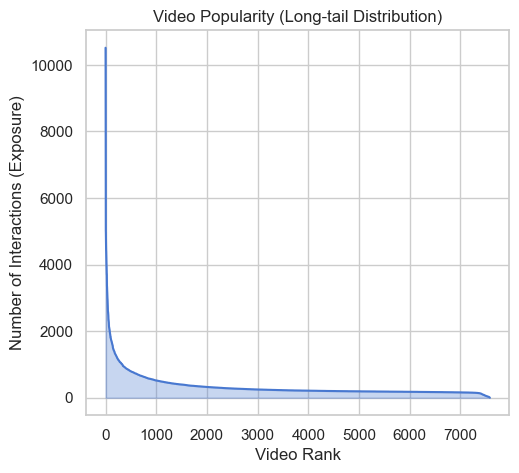

In [29]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(video_counts, color='b')
plt.title('Video Popularity (Long-tail Distribution)')
plt.xlabel('Video Rank')
plt.ylabel('Number of Interactions (Exposure)')
plt.fill_between(range(len(video_counts)), video_counts, alpha=0.3, color='b')

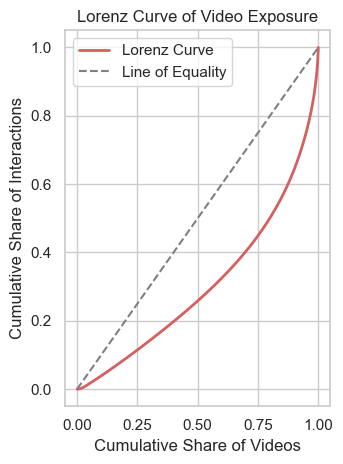

In [30]:
# Lorenz Curve
plt.subplot(1, 2, 2)
sorted_counts = np.sort(video_counts)
cum_counts = np.cumsum(sorted_counts)
lorenz_curve = cum_counts / cum_counts[-1]
x_lorenz = np.arange(1, len(lorenz_curve) + 1) / len(lorenz_curve)
plt.plot(x_lorenz, lorenz_curve, color='r', lw=2, label='Lorenz Curve')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Line of Equality')
plt.title('Lorenz Curve of Video Exposure')
plt.xlabel('Cumulative Share of Videos')
plt.ylabel('Cumulative Share of Interactions')
plt.legend()
plt.tight_layout()
plt.show()

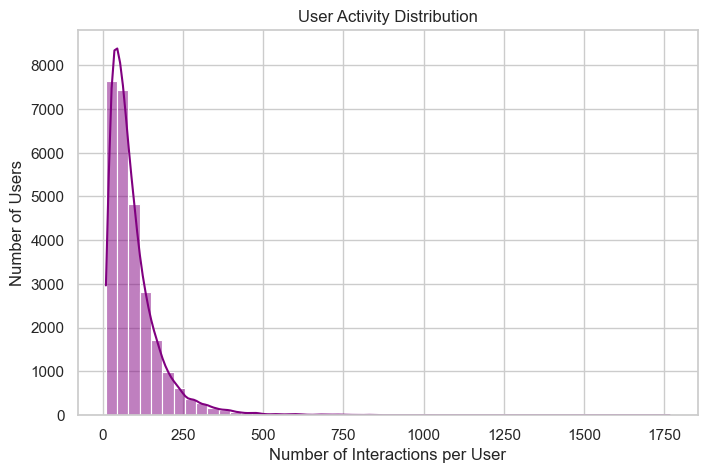

In [31]:
# 2. User Activity Distribution
user_activity = all_logs['user_id'].value_counts()
plt.figure(figsize=(8, 5))
sns.histplot(user_activity, bins=50, kde=True, color='purple')
plt.title('User Activity Distribution')
plt.xlabel('Number of Interactions per User')
plt.ylabel('Number of Users')
plt.show()

## Step 3: Feedback Signal Correlation Analysis

In [32]:
engagement_signals = ['is_like', 'is_comment', 'is_click', 'completion_rate', 'is_follow', 'is_forward']
corr_matrix = all_logs[engagement_signals].corr(method='pearson')

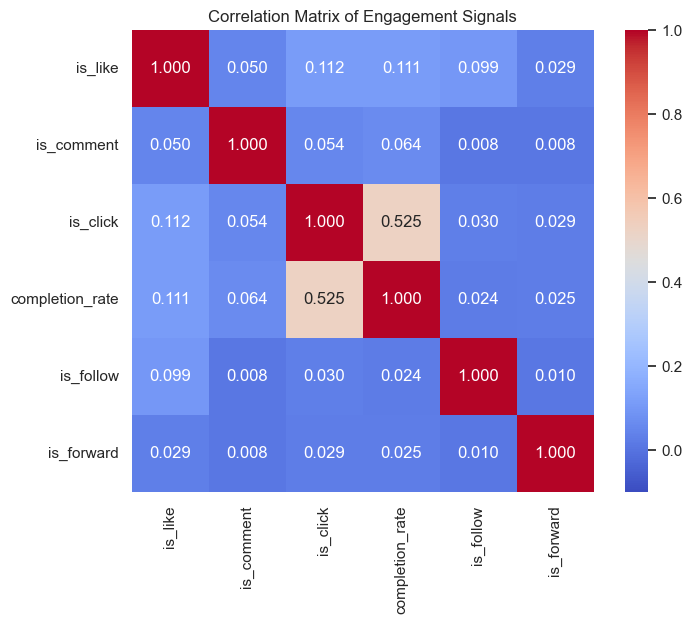

In [33]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap='coolwarm', vmin=-0.1, vmax=1.0, square=True)
plt.title('Correlation Matrix of Engagement Signals')
plt.show()

## Step 4: Standard vs Random Logs Comparison

In [34]:
# Compute completion rate for individual components
df_rand['completion_rate'] = (df_rand['play_time_ms'] / df_rand['duration_ms']).clip(0, 2.0)
df_std['completion_rate'] = (df_std['play_time_ms'] / df_std['duration_ms']).clip(0, 2.0)

In [35]:
# We will compare the average `completion_rate` and `is_like` between the two systems
random_stats = df_rand[['is_like', 'is_click', 'is_comment', 'completion_rate']].mean()
std_stats = df_std[['is_like', 'is_click', 'is_comment', 'completion_rate']].mean()

In [36]:
comparison_df = pd.DataFrame({
    'Random Exposure': random_stats,
    'Standard Recommendation': std_stats
})

In [37]:
print("Performance Comparison:")
print(comparison_df)

Performance Comparison:
                 Random Exposure  Standard Recommendation
is_like                 0.004798                 0.018478
is_click                0.176158                 0.459653
is_comment              0.000347                 0.002546
completion_rate         0.193344                 0.380294


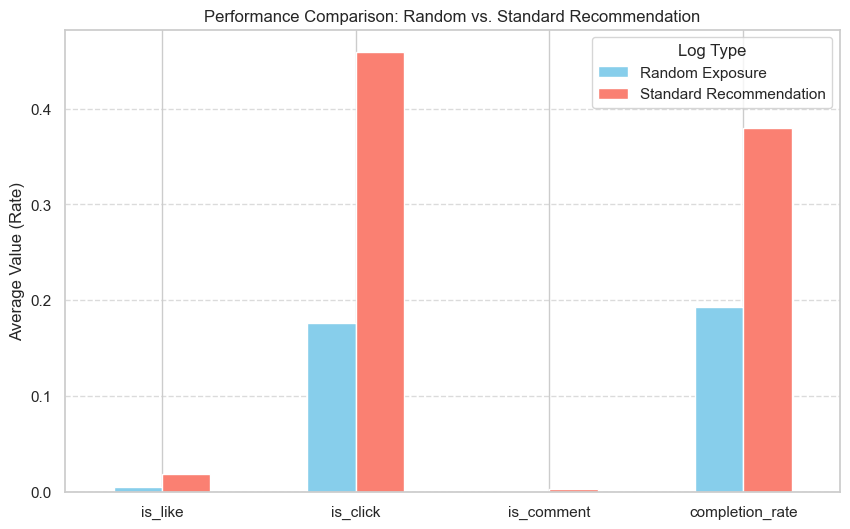

In [38]:
comparison_df.plot(kind='bar', figsize=(10, 6), color=['skyblue', 'salmon'])
plt.title('Performance Comparison: Random vs. Standard Recommendation')
plt.ylabel('Average Value (Rate)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Log Type')
plt.show()

## Step 5: Advanced EDA for Project Storyline
This section provides data-driven evidence to support the business decisions in the recommendation system implementation.

In [39]:
# ### 5.1 Engagement Score Formulation & Distribution
# In industrial recommendations, optimizing for a single metric (like clicks) leads to clickbait. We construct a multi-objective Engagement Score.
# `Score = w1 * is_like + w2 * is_click + w3 * min(play_time/duration, 2.0)`
w1, w2, w3 = 0.5, 0.3, 0.2
all_logs['engagement_score'] = w1 * all_logs['is_like'] + w2 * all_logs['is_click'] + w3 * all_logs['completion_rate']

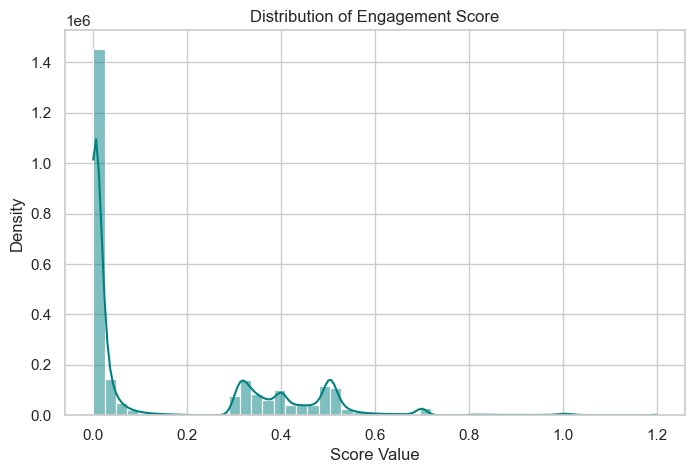

In [40]:
plt.figure(figsize=(8, 5))
sns.histplot(all_logs['engagement_score'], bins=50, kde=True, color='teal')
plt.title('Distribution of Engagement Score')
plt.xlabel('Score Value')
plt.ylabel('Density')
plt.show()
# Observation: The score heavily skewers towards 0 with long tails. Normalization or Log-smoothing might be required before feeding to an SVD model using MSE loss.

In [41]:
# ### 5.2 Temporal Dynamics (for Temporal LOO Validation)
# To simulate real-world production, the Temporal Leave-One-Out (LOO) validates against the strictly "next" user interaction. 
# We analyze user sequence lengths to justify filtering inactive users.
all_logs['hour'] = (all_logs['hourmin'] // 100).astype(int)

In [42]:
plt.figure(figsize=(12, 5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

Text(0, 0.5, 'Total Interactions')

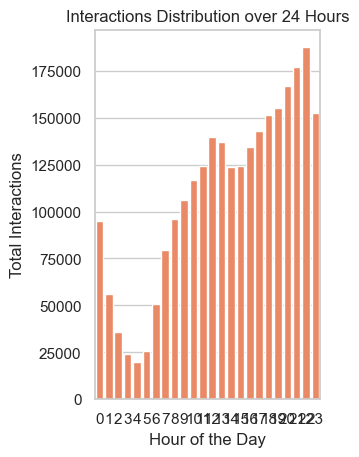

In [43]:
# Plot 1: Activity Heatmap (Hour)
plt.subplot(1, 2, 1)
hourly_activity = all_logs.groupby('hour').size()
sns.barplot(x=hourly_activity.index, y=hourly_activity.values, color='coral')
plt.title('Interactions Distribution over 24 Hours')
plt.xlabel('Hour of the Day')
plt.ylabel('Total Interactions')

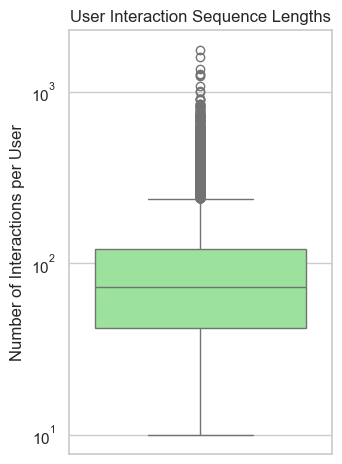

In [44]:
# Plot 2: Sequence Length Boxplot
plt.subplot(1, 2, 2)
sequence_lengths = all_logs.groupby('user_id').size()
sns.boxplot(y=sequence_lengths, color='lightgreen')
plt.title('User Interaction Sequence Lengths')
plt.ylabel('Number of Interactions per User')
plt.yscale('log')
plt.tight_layout()
plt.show()

In [45]:
# ### 5.3 User Profiling (for Cold Start Strategy)
# For users completely lacking interaction history, we can cluster them based on `user_active_degree`.
# Here we check if `user_active_degree` inherently correlates with their video completion rate.
users_combined = pd.merge(all_logs, user_features[['user_id', 'user_active_degree']], on='user_id', how='left')
active_degree_perf = users_combined.groupby('user_active_degree')['completion_rate'].mean().sort_values(ascending=False)

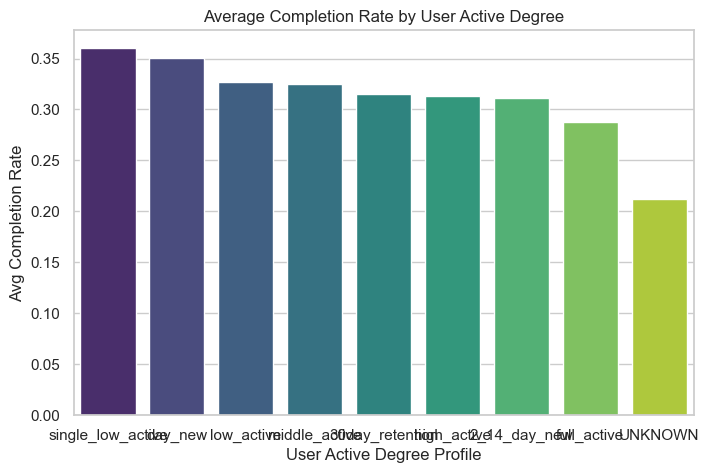

In [46]:
plt.figure(figsize=(8, 5))
sns.barplot(x=active_degree_perf.index, y=active_degree_perf.values, palette='viridis')
plt.title('Average Completion Rate by User Active Degree')
plt.xlabel('User Active Degree Profile')
plt.ylabel('Avg Completion Rate')
plt.show()

### 5.4 Quantifying Popularity Bias (Standard vs Random)
Recommendation Systems (Standard Log) often amplify the "Matthew Effect" (Rich get richer). 
We compare the Lorenz Curve of video exposures between the Standard algorithm and Pure Random exposure.

In [47]:
std_video_counts = df_std['video_id'].value_counts().values
rand_video_counts = df_rand['video_id'].value_counts().values

In [48]:
std_cum = np.cumsum(np.sort(std_video_counts)) / np.sum(std_video_counts)
rand_cum = np.cumsum(np.sort(rand_video_counts)) / np.sum(rand_video_counts)

In [49]:
std_x = np.arange(1, len(std_cum) + 1) / len(std_cum)
rand_x = np.arange(1, len(rand_cum) + 1) / len(rand_cum)

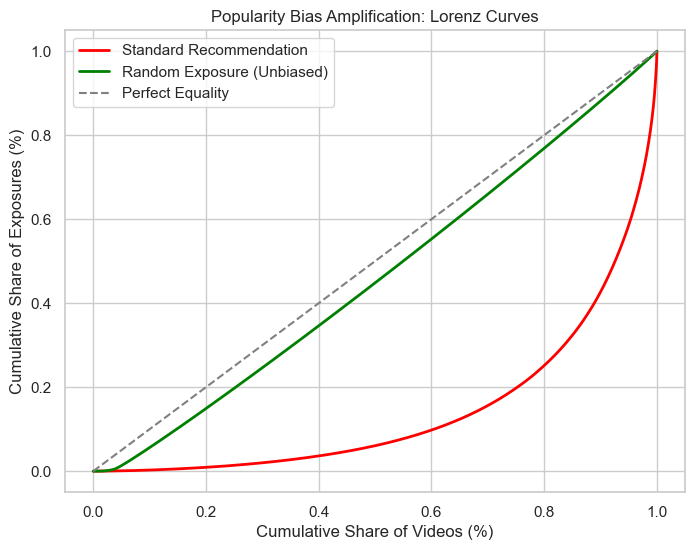

In [50]:
plt.figure(figsize=(8, 6))
plt.plot(std_x, std_cum, label='Standard Recommendation', color='red', lw=2)
plt.plot(rand_x, rand_cum, label='Random Exposure (Unbiased)', color='green', lw=2)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Perfect Equality')
plt.title('Popularity Bias Amplification: Lorenz Curves')
plt.xlabel('Cumulative Share of Videos (%)')
plt.ylabel('Cumulative Share of Exposures (%)')
plt.legend()
plt.show()

In [51]:
# ### 5.5 Negative Sampling Feasibility (1:99 Ratio)
# When evaluating large scale recommendations, Random Negative Sampling (evaluating the positive item alongside 99 randomly selected negative items) is standard.
# This assumes it is highly unlikely that a random item is actually a "positive" item the user hasn't seen yet.
unique_vids_per_user = sequence_lengths  # We analyzed sizes earlier, let's use unique ids
unique_vids_ratio = all_logs.groupby('user_id')['video_id'].nunique() / total_videos * 100

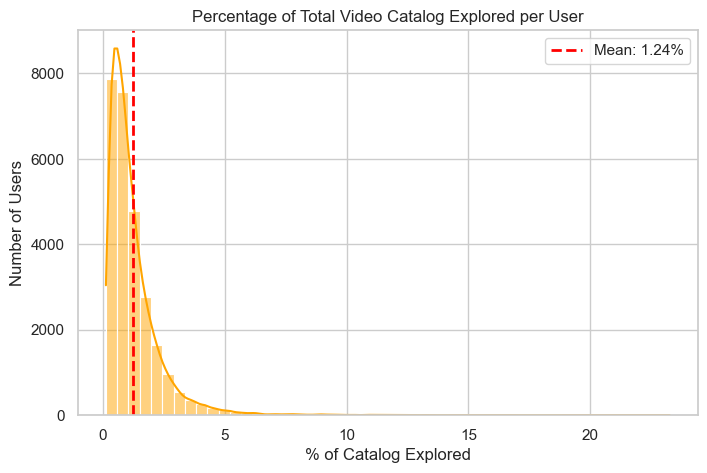

In [52]:
plt.figure(figsize=(8, 5))
sns.histplot(unique_vids_ratio, bins=50, kde=True, color='orange')
plt.axvline(unique_vids_ratio.mean(), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {unique_vids_ratio.mean():.2f}%')
plt.title('Percentage of Total Video Catalog Explored per User')
plt.xlabel('% of Catalog Explored')
plt.ylabel('Number of Users')
plt.legend()
plt.show()